In [ ]:
import pickle
import pandas as pd

# Load the data
num_nodes_values = range(1000, 5001, 1000)
density_values = [0.001, 0.005, 0.01]

In [107]:
import pickle
import pandas as pd

with open('scalar_networknorm_0.01_5000.pkl', 'rb') as f:
    scalar_raw = pickle.load(f)

df = pd.DataFrame.from_dict(scalar_raw).T
df = df.dropna(axis=1)
df = df.corr()
df.dropna(axis=1, how='all', inplace=True)
df.dropna(axis=0, how='all', inplace=True)

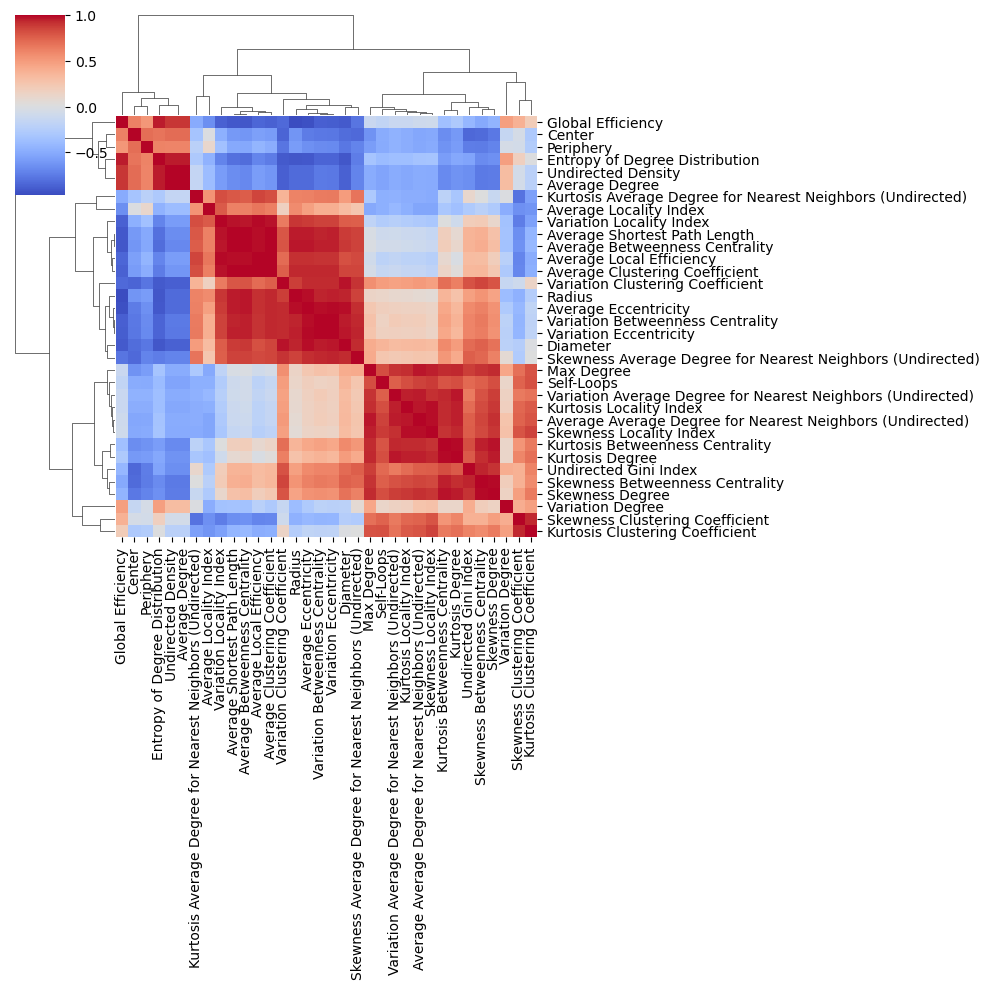

In [ ]:
import seaborn as sns
sns.clustermap(df,xticklabels=True, yticklabels=True, cmap='coolwarm')

In [133]:
from sklearn.feature_selection import mutual_info_regression
import pickle
import pandas as pd

with open('scalar_networknorm_0.01_5000.pkl', 'rb') as f:
    scalar_raw = pickle.load(f)

df = pd.DataFrame.from_dict(scalar_raw).T
df = df.dropna(axis=1)
df

# get mutual information between each pair of df.columns
mi = pd.DataFrame(index=df.columns, columns=df.columns)
for i in df.columns:
    for j in df.columns:
        mi.loc[i,j] = mutual_info_regression(df[[i]], df[j])[0]


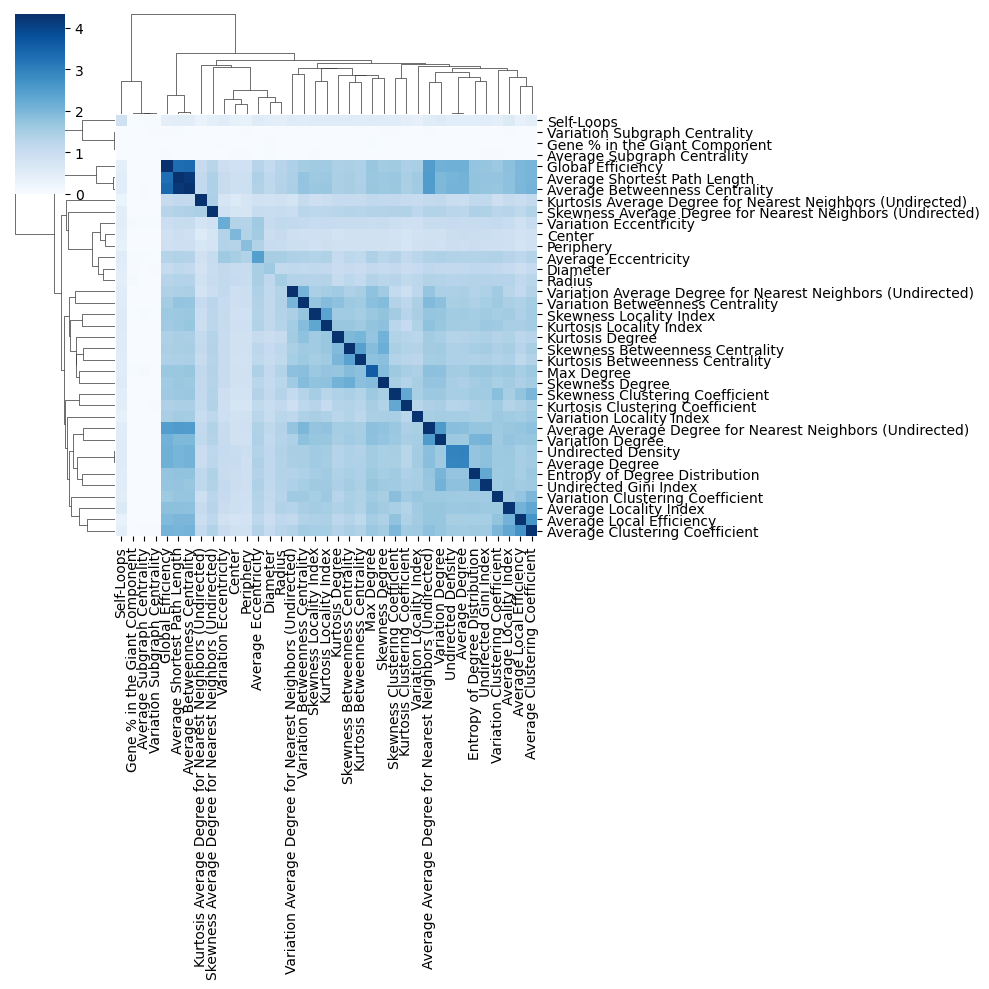

In [141]:
import seaborn as sns
sns.clustermap(mi.astype(float) ,xticklabels=True, yticklabels=True, cmap='Blues', annot=False)

# Edges

In [149]:
with open('edges_0.01_5000.pkl', 'rb') as f:
    edges = pickle.load(f)

type_density_nodes_edges = []
for name, num_edges in edges.items():
    net_type, _, density, num_nodes, _ = name.split('_')
    type_density_nodes_edges.append([net_type, density, num_nodes, num_edges])

In [158]:
df.edges.max()

126143

edges    Axes(0.125,0.11;0.775x0.77)
dtype: object

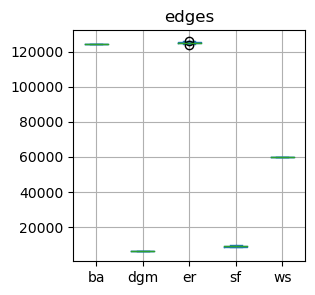

In [168]:
df = pd.DataFrame.from_records(type_density_nodes_edges, columns=['type', 'density', 'nodes', 'edges'], coerce_float=True)
df.plot.box(by='type', column=['edges'], grid=True, figsize=(3,3))

In [175]:
(5000**2)/2*0.01

125000.0

In [188]:
df

,type,density,nodes,edges
0,ba,0.01,5000,124375
1,er,0.01,5000,125192
2,ws,0.01,5000,60000
3,dgm,0.01,5000,6561
4,sf,0.01,5000,8541
...,...,...,...,...
495,ba,0.01,5000,124375
496,er,0.01,5000,125406
497,ws,0.01,5000,60000
498,dgm,0.01,5000,6561


nodes    Axes(0.125,0.11;0.775x0.77)
dtype: object

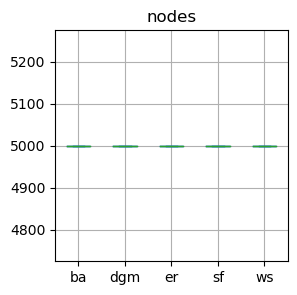

In [176]:
df.nodes = df.nodes.astype(int)
df.plot.box(by='type', column=['nodes'], grid=True, figsize=(3,3))

density    Axes(0.125,0.11;0.775x0.77)
dtype: object

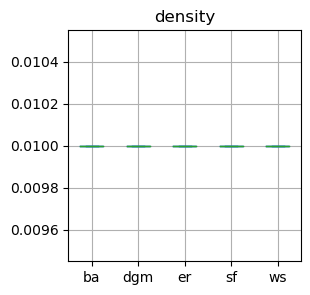

In [185]:
df.density = df.density.astype(float)
df.plot.box(by='type', column=['density'], grid=True, figsize=(3,3))